In [4]:
%pip install numpy pandas tensorflow seaborn matplotlib scikit-learn

  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached tensorflow-2.21.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.11.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.3

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("qoute_dataset.csv")

In [7]:
df.head()

,quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe


In [8]:
df.shape

(3038, 2)

In [9]:
quotes = df["quote"]
quotes.head()

0    “The world as we have created it is a process ...
1    “It is our choices, Harry, that show what we t...
2    “There are only two ways to live your life. On...
3    “The person, be it gentleman or lady, who has ...
4    “Imperfection is beauty, madness is genius and...
Name: quote, dtype: str

In [10]:
quotes = quotes.str.lower()

In [11]:
import string
translator = str.maketrans('', '', string.punctuation)
quotes = quotes.apply(lambda x: x.translate(translator))

In [12]:
quotes.head()

0    “the world as we have created it is a process ...
1    “it is our choices harry that show what we tru...
2    “there are only two ways to live your life one...
3    “the person be it gentleman or lady who has no...
4    “imperfection is beauty madness is genius and ...
Name: quote, dtype: str

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [14]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(quotes)

In [15]:
word_index = tokenizer.word_index
print(len(word_index))
list(word_index.items())[:10]

8978


[('the', 1),
 ('you', 2),
 ('to', 3),
 ('and', 4),
 ('a', 5),
 ('i', 6),
 ('is', 7),
 ('of', 8),
 ('that', 9),
 ('it', 10)]

In [16]:
sequence = tokenizer.texts_to_sequences(quotes)

In [17]:
quotes[0]

'“the world as we have created it is a process of our thinking it cannot be changed without changing our thinking”'

In [18]:
sequence[0]

[713,
 62,
 29,
 19,
 16,
 946,
 10,
 7,
 5,
 1156,
 8,
 70,
 293,
 10,
 145,
 12,
 809,
 104,
 752,
 70,
 2461]

In [19]:
X = []
y = []

for seq in sequence:
  for i in range(1, len(seq)):
    input_seq = seq[:i]
    output_seq = seq[i]
    X.append(input_seq)
    y.append(output_seq)

In [20]:
X

[[713],
 [713, 62],
 [713, 62, 29],
 [713, 62, 29, 19],
 [713, 62, 29, 19, 16],
 [713, 62, 29, 19, 16, 946],
 [713, 62, 29, 19, 16, 946, 10],
 [713, 62, 29, 19, 16, 946, 10, 7],
 [713, 62, 29, 19, 16, 946, 10, 7, 5],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10, 145],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10, 145, 12],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10, 145, 12, 809],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10, 145, 12, 809, 104],
 [713,
  62,
  29,
  19,
  16,
  946,
  10,
  7,
  5,
  1156,
  8,
  70,
  293,
  10,
  145,
  12,
  809,
  104,
  752],
 [713,
  62,
  29,
  19,
  16,
  946,
  10,
  7,
  5,
  1156,
  8,
  70,
  293,
  10,
  145,
  12,
  809,
  

In [21]:
y

[62,
 29,
 19,
 16,
 946,
 10,
 7,
 5,
 1156,
 8,
 70,
 293,
 10,
 145,
 12,
 809,
 104,
 752,
 70,
 2461,
 7,
 70,
 871,
 373,
 9,
 433,
 21,
 19,
 465,
 14,
 294,
 52,
 54,
 70,
 3676,
 14,
 53,
 201,
 714,
 3,
 81,
 15,
 36,
 37,
 7,
 29,
 329,
 93,
 7,
 5,
 1157,
 1,
 101,
 7,
 29,
 329,
 126,
 7,
 5,
 3677,
 116,
 12,
 10,
 2462,
 32,
 1043,
 30,
 82,
 13,
 601,
 11,
 5,
 74,
 1338,
 119,
 12,
 2463,
 3678,
 7,
 313,
 753,
 7,
 638,
 4,
 43,
 144,
 3,
 12,
 682,
 1339,
 54,
 682,
 3680,
 13,
 3,
 202,
 5,
 90,
 8,
 434,
 279,
 202,
 5,
 90,
 8,
 3682,
 7,
 144,
 3,
 12,
 1340,
 17,
 21,
 2,
 14,
 54,
 3,
 12,
 175,
 17,
 21,
 2,
 14,
 3683,
 16,
 13,
 1341,
 191,
 51,
 415,
 2464,
 714,
 9,
 363,
 3684,
 180,
 7,
 39,
 5,
 810,
 1342,
 2,
 46,
 50,
 59,
 322,
 10,
 7,
 168,
 43,
 11,
 639,
 3685,
 111,
 104,
 1045,
 7,
 39,
 2,
 50,
 3686,
 36,
 7,
 21,
 2,
 65,
 10,
 47,
 181,
 21,
 96,
 130,
 3,
 754,
 58,
 123,
 43,
 5,
 1939,
 174,
 18,
 1,
 74,
 208,
 7,
 2,
 94,
 3,
 466,
 5

In [22]:
print(len(X))
print(len(y))

85271
85271


In [23]:
max_len = max(len(x) for x in X)
print(max_len)

745


In [24]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_padded = pad_sequences(X, maxlen=max_len, padding="pre")

In [25]:
X_padded[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [26]:
y = np.array(y)

In [27]:
X_padded.shape

(85271, 745)

In [28]:
y

array([ 62,  29,  19, ...,   3, 169, 101], shape=(85271,))

In [29]:
from tensorflow.keras.utils import to_categorical
y_one_hot = to_categorical(y, num_classes=vocab_size)

In [30]:
print(y.shape)
print(y_one_hot.shape)

(85271,)
(85271, 10000)


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

In [32]:
embedding_dim = 50
rnn_units = 256

In [33]:
rnn_model = Sequential()

rnn_model.add(
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,input_length=max_len)
)

rnn_model.add(
    SimpleRNN(units=rnn_units)
)

rnn_model.add(
    Dense(units=vocab_size, activation="softmax")
)


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [34]:
rnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout

lstm_model = Sequential()

lstm_model.add(
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,input_length=max_len)
)

lstm_model.add(
    LSTM(units=rnn_units)
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    Dense(units=vocab_size, activation="softmax")
)

In [37]:
lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

In [40]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [41]:
epochs = 10
batch_size = 128

history_rnn = rnn_model.fit(
    X_padded,y_one_hot,epochs=epochs,batch_size=batch_size, validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 181s 300ms/step - accuracy: 0.0318 - loss: 7.3978 - val_accuracy: 0.0406 - val_loss: 7.1233
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 184s 306ms/step - accuracy: 0.0474 - loss: 6.5776 - val_accuracy: 0.0517 - val_loss: 6.7948
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 157s 262ms/step - accuracy: 0.0579 - loss: 6.3476 - val_accuracy: 0.0582 - val_loss: 6.7788
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 172s 286ms/step - accuracy: 0.0662 - loss: 6.2023 - val_accuracy: 0.0685 - val_loss: 6.7652
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 158s 263ms/step - accuracy: 0.0755 - loss: 6.0696 - val_accuracy: 0.0697 - val_loss: 6.7366
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 157s 262ms/step - accuracy: 0.0819 - loss: 5.9401 - val_accuracy: 0.0760 - val_loss: 6.7139
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 156s 261ms/step - accuracy: 0.0901 - loss: 5.8124 - val_accuracy: 0.0864 - val_loss: 6.6926
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 154s 257ms/step - accuracy: 0.0995 -

In [42]:
epochs = 100
batch_size = 128

history_lstm = lstm_model.fit(
    X_padded,
    y_one_hot,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 542s 902ms/step - accuracy: 0.0412 - loss: 6.7063 - val_accuracy: 0.0460 - val_loss: 6.6113
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 607s 1s/step - accuracy: 0.0618 - loss: 6.2859 - val_accuracy: 0.0761 - val_loss: 6.4482
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 660s 1s/step - accuracy: 0.0875 - loss: 5.9808 - val_accuracy: 0.0926 - val_loss: 6.3701
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 885s 1s/step - accuracy: 0.1026 - loss: 5.7374 - val_accuracy: 0.1008 - val_loss: 6.3535
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 761s 1s/step - accuracy: 0.1139 - loss: 5.5110 - val_accuracy: 0.1071 - val_loss: 6.3725
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 898s 1s/step - accuracy: 0.1242 - loss: 5.2889 - val_accuracy: 0.1113 - val_loss: 6.4113
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 716s 1s/step - accuracy: 0.1348 - loss: 5.0725 - val_accuracy: 0.1123 - val_loss: 6.4517
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - accuracy: 0.1449 - loss: 4.8583

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

stacked_lstm_model = Sequential()

stacked_lstm_model.add(
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len)
)

stacked_lstm_model.add(
    LSTM(units=rnn_units, return_sequences=True)
)
stacked_lstm_model.add(Dropout(0.2))

stacked_lstm_model.add(
    LSTM(units=rnn_units)
)
stacked_lstm_model.add(Dropout(0.2))

stacked_lstm_model.add(
    Dense(units=vocab_size, activation="softmax")
)

stacked_lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

stacked_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
epochs = 100
batch_size = 128

early_stopping_stacked = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history_stacked_lstm = stacked_lstm_model.fit(
    X_padded,
    y_one_hot,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stopping_stacked]
)

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1489s 2s/step - accuracy: 0.0366 - loss: 6.7968 - val_accuracy: 0.0437 - val_loss: 6.6581
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1546s 3s/step - accuracy: 0.0514 - loss: 6.3987 - val_accuracy: 0.0570 - val_loss: 6.5569
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1564s 3s/step - accuracy: 0.0668 - loss: 6.1714 - val_accuracy: 0.0713 - val_loss: 6.5217
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1586s 3s/step - accuracy: 0.0772 - loss: 6.0021 - val_accuracy: 0.0837 - val_loss: 6.4845
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1534s 3s/step - accuracy: 0.0913 - loss: 5.8414 - val_accuracy: 0.0933 - val_loss: 6.4686
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1558s 3s/step - accuracy: 0.1015 - loss: 5.6777 - val_accuracy: 0.0926 - val_loss: 6.4758
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1456s 2s/step - accuracy: 0.1085 - loss: 5.5176 - val_accuracy: 0.1007 - val_loss: 6.4955
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1314s 2s/step - accuracy: 0.1162 - loss: 5

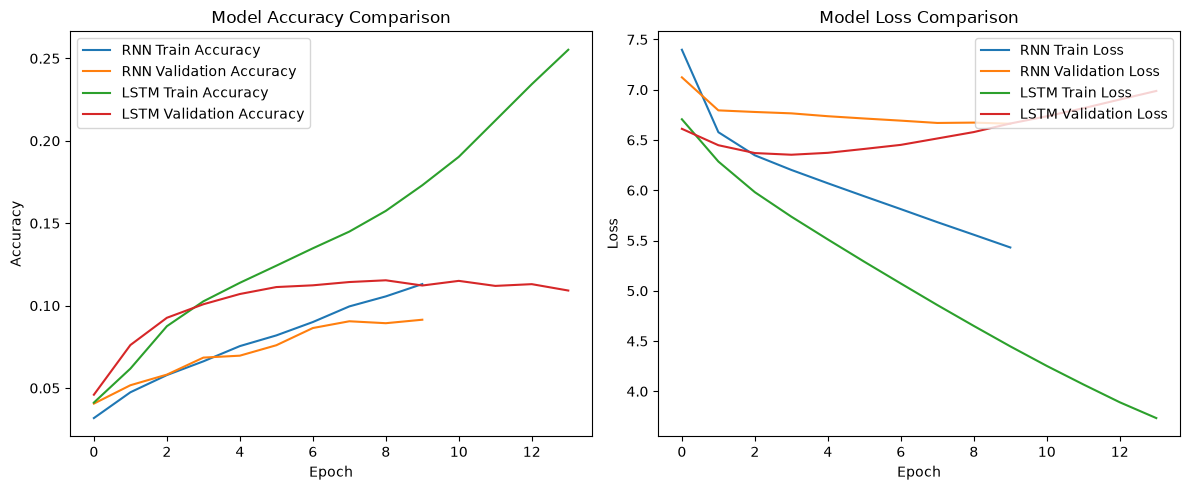

In [45]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='RNN Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Validation Accuracy')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='RNN Train Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')
plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [46]:
lstm_model.save("lstm_model.h5")

In [47]:
index_to_word = {}
for word, index in word_index.items():
  index_to_word[index] = word

In [48]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [49]:
def predictor(model, tokenizer, text, max_len, temperature=1.0):
  text = text.lower()
  seq = tokenizer.texts_to_sequences([text])[0]
  seq = pad_sequences([seq], maxlen=max_len, padding='pre')

  preds = model.predict(seq, verbose=0)[0]

  preds = np.asarray(preds).astype('float64')
  preds = np.log(preds + 1e-10) / temperature
  exp_preds = np.exp(preds)
  preds = exp_preds / np.sum(exp_preds)

  probas = np.random.multinomial(1, preds, 1)[0]
  pred_index = np.argmax(probas)

  return index_to_word.get(pred_index, "")

In [50]:
seed_text = "what are you"
next_word = predictor(lstm_model,tokenizer,seed_text,max_len)
print(next_word)

dont


In [51]:
def generate_text(model, tokenizer, seed_text, max_len, n_words, temperature=1.0):
  for _ in range(n_words):
    next_word = predictor(model, tokenizer, seed_text, max_len, temperature)
    if next_word == "":
      break
    seed_text += " " + next_word
  return seed_text

In [52]:
import numpy as np

seed = "what are you"
print(f"Seed text: '{seed}'")

print("\n--- Generating with temperature = 1.0 ---")
generated_text_default = generate_text(lstm_model, tokenizer, seed, max_len, n_words=10, temperature=1.0)
print(generated_text_default)


print("\n--- Generating with temperature = 0.8 ---")
generated_text_high_temp = generate_text(lstm_model, tokenizer, seed, max_len, n_words=10, temperature=0.8)
print(generated_text_high_temp)

print("\n--- Generating with temperature = 1.2 ---")
generated_text_higher_temp = generate_text(lstm_model, tokenizer, seed, max_len, n_words=10, temperature=1.2)
print(generated_text_higher_temp)

Seed text: 'what are you'

--- Generating with temperature = 1.0 ---
what are you spend the libraries to mean thats than burning a sun

--- Generating with temperature = 0.8 ---
what are you would talk in people are man to be songs you

--- Generating with temperature = 1.2 ---
what are you hope knows every value easier for one sort of hard


In [53]:
seed = "are you a "
generated_text = generate_text(lstm_model,tokenizer,seed,max_len,10)
print(generated_text)

are you a  end of not it is need thats one lies on


In [54]:
import pickle
with open("tokenizer.pkl", "wb") as f:
  pickle.dump(tokenizer, f)

In [55]:
with open("max_len.pkl", "wb") as f:
  pickle.dump(max_len, f)